<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/XGBOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving base.csv.csv to base.csv.csv


In [6]:
df = pd.read_csv("base.csv", sep=";")

In [7]:
# Variables explicatives
X = df[[
    "saison",
    "heure",
    "jour_semaine",
    "ferie",
    "jour_ouvrable",
    "meteo",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "is_special_event"
]].copy()

# Variable cible
y = df["reservations"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (13903, 10)
X_test  : (3476, 10)
y_train : (13903,)
y_test  : (3476,)


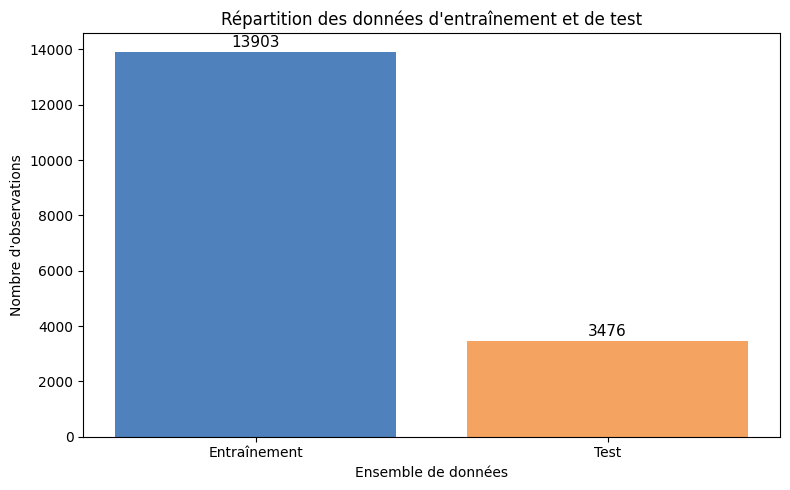

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger la base propre
df = pd.read_csv("base.csv", sep=";")

# Nombre total d'observations
n = len(df)

# Répartition 80% / 20%
train = round(n * 0.8)
test = n - train

# Création du graphique
plt.figure(figsize=(8,5))
plt.bar(["Entraînement", "Test"], [train, test], color=["#4F81BD", "#F4A460"])

# Titre et axes
plt.title("Répartition des données d'entraînement et de test")
plt.xlabel("Ensemble de données")
plt.ylabel("Nombre d'observations")

# Afficher les valeurs sur les barres
for i, v in enumerate([train, test]):
    plt.text(i, v + n*0.01, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [10]:
X = pd.get_dummies(
    X,
    columns=["saison", "jour_semaine", "meteo"],
    drop_first=False
)

In [11]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [12]:
# Recréer une heure numérique à partir de "08h00"
df["heure_num"] = df["heure"].str.replace("h00", "", regex=False).astype(int)

# Encodage cyclique de l’heure
df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

In [13]:
# Variables explicatives
X = df[[
    "saison",
    "jour_semaine",
    "ferie",
    "jour_ouvrable",
    "meteo",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "is_special_event",
    "heure_sin",
    "heure_cos"
]].copy()

# Variable cible
y = df["reservations"]

In [14]:
print(X_train.dtypes[X_train.dtypes == "object"])

heure    object
dtype: object


In [15]:

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# copies pour éviter warnings
X_train = X_train.copy()
X_test = X_test.copy()

# convertir toutes les colonnes texte en category
for col in X_train.columns:
    if X_train[col].dtype == "object":
        X_train[col] = X_train[col].astype("category")
        X_test[col] = X_test[col].astype("category")

# modèle XGBoost
xgb = XGBRegressor(
    objective="reg:squarederror",
    enable_categorical=True,
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = np.maximum(0, y_pred_xgb)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("===== XGBoost =====")
print("MAE  :", round(mae_xgb, 4))
print("RMSE :", round(rmse_xgb, 4))
print("R²   :", round(r2_xgb, 4))

===== XGBoost =====
MAE  : 2.6463
RMSE : 4.1398
R²   : 0.9859


In [16]:

resultats_test = X_test.copy()

# Ajouter les vraies valeurs et les prédictions
resultats_test["reservations_reelles"] = y_test.values if hasattr(y_test, 'values') else y_test
resultats_test["reservations_predites"] = y_pred_xgb

In [17]:

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["date"])

df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour_mois"] = df["date"].dt.day

# Ensure 'heure_num', 'heure_sin', 'heure_cos' are present (from cell GZov7qQQuu84)
# Check if heure_num already exists, otherwise create it.
if "heure_num" not in df.columns:
    df["heure_num"] = df["heure"].str.replace("h00", "", regex=False).astype(int)

# And heure_sin, heure_cos
if "heure_sin" not in df.columns:
    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
if "heure_cos" not in df.columns:
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

# Create a mapping from string day names to numerical values (0-6)
# This inverse mapping is needed to convert df['jour_semaine'] from string to int
string_to_num_jour_semaine = {
    "dimanche": 0,
    "lundi": 1,
    "mardi": 2,
    "mercredi": 3,
    "jeudi": 4,
    "vendredi": 5,
    "samedi": 6
}
# Add a numerical 'jour_semaine_num' column to df
df["jour_semaine_num"] = df["jour_semaine"].map(string_to_num_jour_semaine)


# =========================
# 4. Définir les variables explicatives et la cible
# =========================
features = [
    "saison",
    "jour_semaine", # Keep as string for one-hot encoding in X for the model
    "ferie",
    "jour_ouvrable",
    "meteo",
    "temperature_c", # Corrected from "temperature"
    "humidite_pct",  # Corrected from "humidite"
    "vent_kmh",      # Corrected from "vent"
    "is_special_event",
    "annee",
    "mois",
    "jour_mois",
    "heure_sin",
    "heure_cos"
]

X = df[features].copy() # Use .copy() to avoid SettingWithCopyWarning
y = df["reservations"]

# =========================
# 4.1. One-hot encode categorical features for X
# (consistent with cell OG7jk3enu0AK)
# =========================
X = pd.get_dummies(
    X,
    columns=["saison", "jour_semaine", "meteo"],
    drop_first=False
)

# =========================
# 5. Split chronologique train / test
# =========================
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


# =========================
# 6. Fonctions métier pour la promo
# =========================

def calcul_promo_dynamique(reservations_prevues, min_res, max_res, promo_max=30):
    """
    Calcule une promo de base selon la demande prédite.
    Plus la demande est faible, plus la promo est élevée.
    """
    if max_res == min_res:
        return 0

    ratio = (reservations_prevues - min_res) / (max_res - min_res)
    ratio = max(0, min(ratio, 1))

    promo = promo_max * (1 - ratio)

    # Si la promo est trop faible, on met 0
    if promo < 5:
        return 0

    # Arrondi au multiple de 5 le plus proche
    promo = round(promo / 5) * 5
    return int(promo)


def ajuster_promo_selon_contexte(promo_base, jour_semaine, heure):
    """
    Ajuste légèrement la promo selon le contexte.

    Hypothèse du dataset :
    0 = dimanche
    1 = lundi
    2 = mardi
    3 = mercredi
    4 = jeudi
    5 = vendredi
    6 = samedi
    """
    promo = promo_base

    # Lundi matin : on peut augmenter un peu
    if jour_semaine == 1 and 9 <= heure <= 11:
        promo += 5

    # Mardi à jeudi après-midi : légère hausse
    if jour_semaine in [2, 3, 4] and 14 <= heure <= 17:
        promo += 5

    # Vendredi soir : on réduit légèrement
    if jour_semaine == 5 and 19 <= heure <= 22:
        promo -= 5

    # Week-end midi/soir : on réduit un peu
    if jour_semaine in [0, 6] and (12 <= heure <= 15 or 19 <= heure <= 21):
        promo -= 5

    promo = max(0, min(promo, 30))

    if promo == 0:
        return 0

    promo = round(promo / 5) * 5
    return int(promo)


def recommander_promo_finale(reservations_prevues, jour_semaine, heure, min_res, max_res, seuil_forte_demande, promo_max=30):
    """
    Règle globale :
    si la demande prédite est forte, aucune promo.
    Sinon :
    - calcul promo dynamique
    - ajustement selon jour/heure
    """
    # Règle prioritaire : forte demande => pas de promo
    if reservations_prevues >= seuil_forte_demande:
        return 0

    # Promo de base
    promo_base = calcul_promo_dynamique(
        reservations_prevues=reservations_prevues,
        min_res=min_res,
        max_res=max_res,
        promo_max=promo_max
    )

    # Ajustement selon le contexte
    promo_finale = ajuster_promo_selon_contexte(
        promo_base=promo_base,
        jour_semaine=jour_semaine,
        heure=heure
    )

    return promo_finale


def format_heure(h):
    """
    Formater l'heure sous forme 12h00, 19h00, etc.
    """
    return f"{int(h):02d}h00"


# =========================
# 7. Générer la promo finale
# =========================
min_res = y_train.min()
max_res = y_train.max()

# Seuil de forte demande :
# si reservations_prevues >= ce seuil => pas de promo
seuil_forte_demande = y_train.quantile(0.75)

# Use the numerical 'jour_semaine_num' for calculations
jours_test = df.iloc[split_index:]["jour_semaine_num"].values
heures_test = df.iloc[split_index:]["heure_num"].values # Corrected to heure_num

# Using y_pred_xgb, which was computed in cell zx9p-lX1EOSl
promo_finale = [
    recommander_promo_finale(
        reservations_prevues=pred,
        jour_semaine=jour,
        heure=heure,
        min_res=min_res,
        max_res=max_res,
        seuil_forte_demande=seuil_forte_demande,
        promo_max=30
    )
    for pred, jour, heure in zip(y_pred_xgb, jours_test, heures_test)
]


# =========================
# 8. Ajouter les noms des jours
# =========================
mapping_jours = {
    0: "dimanche",
    1: "lundi",
    2: "mardi",
    3: "mercredi",
    4: "jeudi",
    5: "vendredi",
    6: "samedi"
}

# jours_noms_test will now correctly map numerical days to names
jours_noms_test = [mapping_jours.get(j, "inconnu") for j in jours_test]


# =========================
# 9. Créer le tableau final
# =========================
resultats = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "jour_semaine": jours_test, # This will now be numerical
    "jour_nom": jours_noms_test,
    "heure": heures_test,
    "heure_affichage": [format_heure(h) for h in heures_test],
    "reservations_reelles": y_test.values,
    "reservations_prevues": np.round(y_pred_xgb, 2),
    "promo_finale": promo_finale
})

# Colonne d'affichage de la promo sous forme "20%"
resultats["promo_affichage"] = resultats["promo_finale"].astype(str) + "%"

# Réorganiser les colonnes
resultats = resultats[
    [
        "date",
        "jour_nom",
        "heure_affichage",
        "reservations_reelles",
        "reservations_prevues",
        "promo_finale",
        "promo_affichage"
    ]
]


# =========================
# 10. Afficher les résultats
# =========================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(resultats.head(10).to_string(index=False))


      date jour_nom heure_affichage  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2012-08-07    mardi           12h00                    57             63.759998             0              0%
2012-08-07    mardi           13h00                    60             70.620003             0              0%
2012-08-07    mardi           14h00                    38             46.790001            25             25%
2012-08-07    mardi           15h00                    31             29.570000            30             30%
2012-08-07    mardi           16h00                    25             25.360001            30             30%
2012-08-07    mardi           17h00                    36             38.049999            25             25%
2012-08-07    mardi           18h00                    66             60.459999             0              0%
2012-08-07    mardi           19h00                    86             87.639999             0              0%
2012-08-07

In [22]:

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["date"])

df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour_mois"] = df["date"].dt.day

# Ensure 'heure_num', 'heure_sin', 'heure_cos' are present (from cell GZov7qQQuu84)
# Check if heure_num already exists, otherwise create it.
if "heure_num" not in df.columns:
    df["heure_num"] = df["heure"].str.replace("h00", "", regex=False).astype(int)

# And heure_sin, heure_cos
if "heure_sin" not in df.columns:
    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
if "heure_cos" not in df.columns:
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

# Create a mapping from string day names to numerical values (0-6)
# This inverse mapping is needed to convert df['jour_semaine'] from string to int
string_to_num_jour_semaine = {
    "dimanche": 0,
    "lundi": 1,
    "mardi": 2,
    "mercredi": 3,
    "jeudi": 4,
    "vendredi": 5,
    "samedi": 6
}
# Add a numerical 'jour_semaine_num' column to df
df["jour_semaine_num"] = df["jour_semaine"].map(string_to_num_jour_semaine)


# =========================
# 4. Définir les variables explicatives et la cible
# =========================
features = [
    "saison",
    "jour_semaine", # Keep as string for one-hot encoding in X for the model
    "ferie",
    "jour_ouvrable",
    "meteo",
    "temperature_c", # Corrected from "temperature"
    "humidite_pct",  # Corrected from "humidite"
    "vent_kmh",      # Corrected from "vent"
    "is_special_event",
    "annee",
    "mois",
    "jour_mois",
    "heure_sin",
    "heure_cos"
]

X = df[features].copy() # Use .copy() to avoid SettingWithCopyWarning
y = df["reservations"]

# =========================
# 4.1. One-hot encode categorical features for X
# (consistent with cell OG7jk3enu0AK)
# =========================
X = pd.get_dummies(
    X,
    columns=["saison", "jour_semaine", "meteo"],
    drop_first=False
)

# =========================
# 5. Split chronologique train / test
# =========================
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# =========================
# 6. Fonctions métier pour la promo (version enrichie)
# =========================

# Paramètres configurables (à ajuster après tests)
CFG = {
    "promo_max": 30,
    "seuil_forte_demande_quantile": 0.75,

    # ajustements contextuels
    "bonus_meteo_defavorable": 5,      # pluie / vent fort / météo défavorable
    "malus_jour_ferie": 5,             # on réduit la promo si c'est férié
    "malus_evenement_fort": 10,        # on réduit davantage si grand événement
    "bonus_creux_horaire": 5,          # créneau creux
    "plafond": 30,
    "plancher": 0
}


def calcul_promo_dynamique(reservations_prevues, min_res, max_res, promo_max=30):
    """
    Promo de base selon la demande prédite :
    demande faible => promo plus élevée
    demande forte => promo plus faible
    """
    if max_res == min_res:
        return 0

    ratio = (reservations_prevues - min_res) / (max_res - min_res)
    ratio = max(0, min(ratio, 1))

    promo = promo_max * (1 - ratio)

    # si trop faible, on ne met rien
    if promo < 5:
        return 0

    promo = round(promo / 5) * 5
    return int(promo)


def ajuster_promo_selon_contexte(
    promo_base,
    jour_semaine,
    heure,
    meteo,
    ferie,
    is_special_event,
    nom_evenement=""
):
    """
    Ajustement promo selon :
    - jour / heure
    - météo
    - jour férié
    - événement
    """

    promo = promo_base
    meteo = str(meteo).strip().lower()
    nom_evenement = str(nom_evenement).strip().lower()

    # -------------------------
    # A) Ajustement jour / heure
    # -------------------------
    # 0 = dimanche, 1 = lundi, ..., 6 = samedi
    if jour_semaine == 1 and 9 <= heure <= 11:   # lundi matin
        promo += CFG["bonus_creux_horaire"]

    if jour_semaine in [2, 3, 4] and 14 <= heure <= 17:  # mardi-jeudi après-midi
        promo += CFG["bonus_creux_horaire"]

    if jour_semaine == 5 and 19 <= heure <= 22:  # vendredi soir
        promo -= 5

    if jour_semaine in [0, 6] and (12 <= heure <= 15 or 19 <= heure <= 21):  # week-end midi/soir
        promo -= 5

    # -------------------------
    # B) Ajustement météo
    # -------------------------
    # Exemple de logique :
    # météo défavorable => on peut augmenter légèrement
    if meteo in ["pluvieux", "venteux", "orageux", "nuageux"]:
        promo += CFG["bonus_meteo_defavorable"]

    # météo très favorable + créneau déjà attractif => on réduit un peu
    if meteo in ["ensoleillé", "ensoleille"] and jour_semaine in [5, 6, 0] and 12 <= heure <= 21:
        promo -= 5

    # -------------------------
    # C) Ajustement jour férié
    # -------------------------
    if int(ferie) == 1:
        promo -= CFG["malus_jour_ferie"]

    # -------------------------
    # D) Ajustement événement
    # -------------------------
    if int(is_special_event) == 1:
        # si gros événement, on réduit plus fortement
        keywords_event_fort = [
            "champions league",
            "ligue des champions",
            "finale",
            "derby",
            "concert",
            "festival",
            "match"
        ]

        if any(k in nom_evenement for k in keywords_event_fort):
            promo -= CFG["malus_evenement_fort"]
        else:
            promo -= 5

    # bornes
    promo = max(CFG["plancher"], min(promo, CFG["plafond"]))

    if promo == 0:
        return 0

    promo = round(promo / 5) * 5
    return int(promo)


def recommander_promo_finale(
    reservations_prevues,
    jour_semaine,
    heure,
    meteo,
    ferie,
    is_special_event,
    nom_evenement,
    min_res,
    max_res,
    seuil_forte_demande,
    promo_max=30
):
    """
    Logique globale :
    1) si demande très forte => pas de promo
    2) sinon, promo de base selon la demande
    3) puis ajustement selon contexte :
       - jour / heure
       - météo
       - férié
       - événement
    """

    # Règle prioritaire : si forte demande => pas de promo
    if reservations_prevues >= seuil_forte_demande:
        return 0

    promo_base = calcul_promo_dynamique(
        reservations_prevues=reservations_prevues,
        min_res=min_res,
        max_res=max_res,
        promo_max=promo_max
    )

    promo_finale = ajuster_promo_selon_contexte(
        promo_base=promo_base,
        jour_semaine=jour_semaine,
        heure=heure,
        meteo=meteo,
        ferie=ferie,
        is_special_event=is_special_event,
        nom_evenement=nom_evenement
    )

    return promo_finale


def format_heure(h):
    return f"{int(h):02d}h00"


# =========================
# 7. Générer la promo finale
# =========================
min_res = y_train.min()
max_res = y_train.max()

seuil_forte_demande = y_train.quantile(CFG["seuil_forte_demande_quantile"])

# Variables de contexte sur le test
jours_test = df.iloc[split_index:]["jour_semaine_num"].values
heures_test = df.iloc[split_index:]["heure_num"].values
meteo_test = df.iloc[split_index:]["meteo"].values
ferie_test = df.iloc[split_index:]["ferie"].values
is_special_event_test = df.iloc[split_index:]["is_special_event"].values
nom_evenement_test = df.iloc[split_index:]["nom_evenement"].values
nom_ferie_test = df.iloc[split_index:]["nom_ferie"].values

promo_finale = [
    recommander_promo_finale(
        reservations_prevues=pred,
        jour_semaine=jour,
        heure=heure,
        meteo=meteo,
        ferie=ferie,
        is_special_event=is_evt,
        nom_evenement=evt_name,
        min_res=min_res,
        max_res=max_res,
        seuil_forte_demande=seuil_forte_demande,
        promo_max=CFG["promo_max"]
    )
    for pred, jour, heure, meteo, ferie, is_evt, evt_name in zip(
        y_pred_xgb,
        jours_test,
        heures_test,
        meteo_test,
        ferie_test,
        is_special_event_test,
        nom_evenement_test
    )
]

# =========================
# 8. Ajouter les noms des jours
# =========================
mapping_jours = {
    0: "dimanche",
    1: "lundi",
    2: "mardi",
    3: "mercredi",
    4: "jeudi",
    5: "vendredi",
    6: "samedi"
}

# jours_noms_test will now correctly map numerical days to names
jours_noms_test = [mapping_jours.get(j, "inconnu") for j in jours_test]


# =========================
# 9. Créer le tableau final
# =========================
resultats = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "jour_semaine": jours_test,
    "jour_nom": jours_noms_test,
    "heure": heures_test,
    "heure_affichage": [format_heure(h) for h in heures_test],

    # nouvelles colonnes contexte
    "meteo": meteo_test,
    "ferie": ferie_test,
    "nom_ferie": nom_ferie_test,
    "is_special_event": is_special_event_test,
    "nom_evenement": nom_evenement_test,

    # résultats
    "reservations_reelles": y_test.values,
    "reservations_prevues": np.round(y_pred_xgb, 2),
    "promo_finale": promo_finale
})

resultats["promo_affichage"] = resultats["promo_finale"].astype(str) + "%"

# Réorganiser les colonnes
resultats = resultats[
    [
        "date",
        "jour_nom",
        "heure_affichage",
        "meteo",
        "ferie",
        "nom_ferie",
        "is_special_event",
        "nom_evenement",
        "reservations_reelles",
        "reservations_prevues",
        "promo_finale",
        "promo_affichage"
    ]
]

# =========================
# 10. Afficher les résultats
# =========================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1500)

print(resultats.head(10).to_string(index=False))






      date jour_nom heure_affichage      meteo  ferie nom_ferie  is_special_event nom_evenement  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2012-08-07    mardi           12h00    nuageux      0     Aucun                 0         Aucun                    57             63.759998             0              0%
2012-08-07    mardi           13h00    nuageux      0     Aucun                 0         Aucun                    60             70.620003             0              0%
2012-08-07    mardi           14h00    nuageux      0     Aucun                 0         Aucun                    38             46.790001            30             30%
2012-08-07    mardi           15h00 ensoleillé      0     Aucun                 0         Aucun                    31             29.570000            30             30%
2012-08-07    mardi           16h00   pluvieux      0     Aucun                 0         Aucun                    25             25.360001           

In [33]:
from google.colab import files
uploaded = files.upload()

Saving base_propre_corrigee_sans_feries_tn_plus_france.csv to base_propre_corrigee_sans_feries_tn_plus_france.csv


In [34]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBRegressor

# =========================
# 1) Charger la base
# =========================
input_file = "base_propre.csv"
sep = ";"

df = pd.read_csv(input_file, sep=sep, dtype=str, keep_default_na=False)
df.columns = [c.replace("\\_", "_") for c in df.columns]

# =========================
# 2) Préparer la date
# =========================
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["date"])

df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour_mois"] = df["date"].dt.day

# =========================
# 3) Préparer l'heure
# =========================
if "heure_num" not in df.columns:
    df["heure_num"] = df["heure"].str.replace("h00", "", regex=False).astype(int)

if "heure_sin" not in df.columns:
    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)

if "heure_cos" not in df.columns:
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

# =========================
# 4) Mapping jour_semaine -> numérique
#    (utile pour analyse future / promo)
# =========================
string_to_num_jour_semaine = {
    "dimanche": 0,
    "lundi": 1,
    "mardi": 2,
    "mercredi": 3,
    "jeudi": 4,
    "vendredi": 5,
    "samedi": 6
}

df["jour_semaine_num"] = df["jour_semaine"].map(string_to_num_jour_semaine)

# =========================
# 5) Colonnes numériques
# =========================
numeric_cols = [
    "ferie",
    "jour_ouvrable",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "is_special_event",
    "capacite_max",
    "reservations"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remplacer quelques valeurs vides texte
for col in ["nom_ferie", "nom_evenement", "meteo", "saison", "jour_semaine"]:
    if col in df.columns:
        df[col] = df[col].replace("", "Aucun").fillna("Aucun")

# Supprimer les lignes où la cible est absente
df = df.dropna(subset=["reservations"])

# =========================
# 6) Définir les features
# =========================
features = [
    "saison",
    "jour_semaine",
    "ferie",
    "nom_ferie",
    "jour_ouvrable",
    "meteo",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "is_special_event",
    "nom_evenement",
    "capacite_max",
    "annee",
    "mois",
    "jour_mois",
    "heure_sin",
    "heure_cos"
]

target = "reservations"

X = df[features].copy()
y = df[target].copy()

# =========================
# 7) One-hot encoding
# =========================
categorical_cols = [
    "saison",
    "jour_semaine",
    "nom_ferie",
    "meteo",
    "nom_evenement"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False
)

# Sauvegarder les colonnes du modèle
model_columns = X.columns.tolist()

# =========================
# 8) Split chronologique train / test
# =========================
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# =========================
# 9) Entraîner le modèle
# =========================
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# =========================
# 10) Prédictions
# =========================
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = np.maximum(0, y_pred_xgb)
# =========================
# 10. Fonctions promo
# =========================

CFG_PROMO = {
    "promo_max": 30,
    "seuil_forte_demande_quantile": 0.75,
    "bonus_meteo_defavorable": 5,
    "malus_jour_ferie": 5,
    "malus_evenement": 5,
    "plafond": 30,
    "plancher": 0
}

def calcul_promo_dynamique(reservations_prevues, min_res, max_res, promo_max=30):
    """
    Promo de base selon la demande prédite.
    Plus la demande est faible, plus la promo peut être élevée.
    """
    if max_res == min_res:
        return 0

    ratio = (reservations_prevues - min_res) / (max_res - min_res)
    ratio = max(0, min(ratio, 1))

    promo = promo_max * (1 - ratio)

    if promo < 5:
        return 0

    promo = round(promo / 5) * 5
    return int(promo)


def ajuster_promo_selon_contexte(promo_base, jour_semaine, heure, meteo, ferie, is_special_event):
    """
    Ajustement simple selon contexte.
    """
    promo = promo_base
    meteo = str(meteo).strip().lower()

    # Heure / jour
    if jour_semaine == 1 and 9 <= heure <= 11:   # lundi matin
        promo += 5

    if jour_semaine in [2, 3, 4] and 14 <= heure <= 17:  # mardi-jeudi après-midi
        promo += 5

    if jour_semaine == 5 and 19 <= heure <= 22:  # vendredi soir
        promo -= 5

    if jour_semaine in [0, 6] and (12 <= heure <= 15 or 19 <= heure <= 21):  # week-end
        promo -= 5

    # Météo défavorable
    if meteo in ["pluvieux", "venteux", "nuageux", "orageux"]:
        promo += CFG_PROMO["bonus_meteo_defavorable"]

    # Jour férié
    if int(ferie) == 1:
        promo -= CFG_PROMO["malus_jour_ferie"]

    # Événement spécial
    if int(is_special_event) == 1:
        promo -= CFG_PROMO["malus_evenement"]

    promo = max(CFG_PROMO["plancher"], min(promo, CFG_PROMO["plafond"]))

    if promo == 0:
        return 0

    promo = round(promo / 5) * 5
    return int(promo)


def recommander_promo_finale(
    reservations_prevues,
    jour_semaine,
    heure,
    meteo,
    ferie,
    is_special_event,
    min_res,
    max_res,
    seuil_forte_demande,
    promo_max=30
):
    """
    Si forte demande => pas de promo.
    Sinon :
    - promo de base selon demande prédite
    - ajustement selon météo / férié / événement / heure / jour
    """
    if reservations_prevues >= seuil_forte_demande:
        return 0

    promo_base = calcul_promo_dynamique(
        reservations_prevues=reservations_prevues,
        min_res=min_res,
        max_res=max_res,
        promo_max=promo_max
    )

    promo_finale = ajuster_promo_selon_contexte(
        promo_base=promo_base,
        jour_semaine=jour_semaine,
        heure=heure,
        meteo=meteo,
        ferie=ferie,
        is_special_event=is_special_event
    )

    return promo_finale


# =========================
# 11. Générer la promo finale
# =========================

min_res = y_train.min()
max_res = y_train.max()
seuil_forte_demande = y_train.quantile(CFG_PROMO["seuil_forte_demande_quantile"])

jours_test = df.iloc[split_index:]["jour_semaine_num"].values
heures_test = df.iloc[split_index:]["heure_num"].values
meteo_test = df.iloc[split_index:]["meteo"].values
ferie_test = df.iloc[split_index:]["ferie"].values
is_special_event_test = df.iloc[split_index:]["is_special_event"].values

promo_finale = [
    recommander_promo_finale(
        reservations_prevues=pred,
        jour_semaine=jour,
        heure=heure,
        meteo=meteo,
        ferie=ferie,
        is_special_event=is_evt,
        min_res=min_res,
        max_res=max_res,
        seuil_forte_demande=seuil_forte_demande,
        promo_max=CFG_PROMO["promo_max"]
    )
    for pred, jour, heure, meteo, ferie, is_evt in zip(
        y_pred_xgb,
        jours_test,
        heures_test,
        meteo_test,
        ferie_test,
        is_special_event_test
    )
]

# =========================
# 12. Tableau final avec promo
# =========================

mapping_jours = {
    0: "dimanche",
    1: "lundi",
    2: "mardi",
    3: "mercredi",
    4: "jeudi",
    5: "vendredi",
    6: "samedi"
}

jours_noms_test = [mapping_jours.get(j, "inconnu") for j in jours_test]

def format_heure(h):
    return f"{int(h):02d}h00"

resultats_modele = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "jour_nom": jours_noms_test,
    "heure_affichage": [format_heure(h) for h in heures_test],
    "meteo": meteo_test,
    "ferie": ferie_test,
    "nom_ferie": df.iloc[split_index:]["nom_ferie"].values,
    "is_special_event": is_special_event_test,
    "nom_evenement": df.iloc[split_index:]["nom_evenement"].values,
    "reservations_reelles": y_test.values,
    "reservations_prevues": np.round(y_pred_xgb, 2),
    "promo_finale": promo_finale
})

resultats_modele["promo_affichage"] = resultats_modele["promo_finale"].astype(str) + "%"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1500)

print(resultats_modele.head(100).to_string(index=False))





      date jour_nom heure_affichage      meteo  ferie nom_ferie  is_special_event nom_evenement  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2012-08-07    mardi           12h00    nuageux      0     Aucun                 0         Aucun                    57             63.290001             0              0%
2012-08-07    mardi           13h00    nuageux      0     Aucun                 0         Aucun                    60             68.959999             0              0%
2012-08-07    mardi           14h00    nuageux      0     Aucun                 0         Aucun                    38             48.299999            30             30%
2012-08-07    mardi           15h00 ensoleillé      0     Aucun                 0         Aucun                    31             31.629999            30             30%
2012-08-07    mardi           16h00   pluvieux      0     Aucun                 0         Aucun                    25             24.299999           

In [36]:
feries = resultats_modele[resultats_modele["ferie"].astype(int) == 1].copy()

print(feries[
    [
        "date",
        "jour_nom",
        "heure_affichage",
        "nom_ferie",
        "meteo",
        "is_special_event",
        "nom_evenement",
        "reservations_reelles",
        "reservations_prevues",
        "promo_finale",
        "promo_affichage"
    ]
].head(10).to_string(index=False))

      date jour_nom heure_affichage  nom_ferie      meteo  is_special_event nom_evenement  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2012-08-15 mercredi           00h00 Assomption ensoleillé                 0         Aucun                     0                  0.00            25             25%
2012-08-15 mercredi           01h00 Assomption ensoleillé                 0         Aucun                     1                  0.02            25             25%
2012-08-15 mercredi           02h00 Assomption ensoleillé                 0         Aucun                     1                  0.42            25             25%
2012-08-15 mercredi           03h00 Assomption ensoleillé                 0         Aucun                     1                  0.56            25             25%
2012-08-15 mercredi           04h00 Assomption ensoleillé                 0         Aucun                     0                  0.59            25             25%
2012-08-15 mercr